In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from omegaconf import OmegaConf
from loguru import logger as lgr_logger
from matplotlib.colors import TwoSlopeNorm
from sunpy.visualization.colormaps import color_tables

from sdofmv2.core import MAE, SDOMLDataModule, inverse_log_norm
from sdofmv2.utils import ALL_COMPONENTS

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/sympy/external/gmpy.py:139: UserWarning: gmpy2 version is too old to use (2.0.0 or newer required)
  gmpy = import_module('gmpy2', min_module_version=_GMPY2_MIN_VERSION,
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def mask_overlay(input_img, mask_grid, alpha=0.7):
    img = input_img.clone()
    overlay = np.zeros_like(img)
    overlay[..., 0] = 30  # red channel

    for i in range(mask_grid.shape[0]):
        for j in range(mask_grid.shape[1]):
            if mask_grid[i, j] == 1:
                y0, y1 = i * 16, (i + 1) * 16
                x0, x1 = j * 16, (j + 1) * 16
                img[y0:y1, x0:x1] = (1 - alpha) * img[y0:y1, x0:x1] + alpha * overlay[y0:y1, x0:x1]
    
    return img


In [3]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_HMI.yaml"
    )

In [4]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()

2026-04-02 01:19:53.865 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:994 - Cache is found: ../../assets/cache/HMI/Bx_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-04-02 01:19:53.866 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:994 - Cache is found: ../../assets/cache/HMI/By_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-04-02 01:19:53.866 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:994 - Cache is found: ../../assets/cache/HMI/Bz_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-04-02 01:19:53.874 | INFO     | sdofmv2.core.datamodule:setup:1140 - Train dataloader is ready!
2026-04-02 01:19:53.874 | INFO     | sdofmv2.core.datamodule:setup:1141 - Dataset size: 284813
2026-04-02 01:19:53.878 | INFO     | sdofmv2.core.datamodule:setup:1163 - Validation dataloader is ready!
2026-04-02 01:19:53.879 | INFO     | sdofmv2.core.datamodule:setup:1164 - Dataset size: 30533
2026-04-02 01:19:53.883 | INFO     | sdofmv2.c

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_HMI_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.
[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


In [5]:
components = ALL_COMPONENTS
components.sort()

In [6]:
base_path = "../../assets/check_point/backbone/"

model = MAE.load_from_checkpoint(
    checkpoint_path=base_path+"HMI/id_23znhw58_mae_epoch=244-val_loss=0.00.ckpt",
    map_location="cpu",
    weights_only=False)
lgr_logger.info(f"masking ratio of sdofmv2: {model.masking_ratio}")

model_no_mask = MAE.load_from_checkpoint(
    checkpoint_path=base_path+"HMI/id_23znhw58_mae_epoch=244-val_loss=0.00.ckpt",
    map_location="cpu",
    weights_only=False)
model_no_mask.masking_ratio = 0
lgr_logger.info(f"masking ratio of sdofmv2: {model_no_mask.masking_ratio}")

2026-04-02 01:20:18.944 | INFO     | __main__:<module>:7 - masking ratio of sdofmv2: 0.25
2026-04-02 01:20:19.858 | INFO     | __main__:<module>:14 - masking ratio of sdofmv2: 0


In [7]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00')]


In [8]:
model.eval()

with torch.no_grad():
    output = model(x_set)
    output_no_mask = model_no_mask(x_set)

# norm information
norm_stat = {"HMI": {}}
for ch_id, ch in enumerate(components):
    
    cache_path = "../../assets/cache/HMI/"
    file_name = (
        ch
        + "_"
        + "_".join(data_module.cache_id.split("_")[-1:])
        + f"_norm-{data_module.normalization.type}"
        + ".json"
    )

    with open(cache_path + file_name, "r") as json_file:
        ch_stat = json.load(json_file)
    
    norm_stat["HMI"][ch] = ch_stat

# input/output inverse log transform for visualization
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(components):

        output[0][i_img, ch_id, 0, :, :] = inverse_log_norm(
            output[0][i_img, ch_id, 0, :, :],
            norm_stat,
            "HMI",
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
            cfg.data.sdoml.normalization.scaler_div_factor
        )

        output_no_mask[0][i_img, ch_id, 0, :, :] = inverse_log_norm(
            output_no_mask[0][i_img, ch_id, 0, :, :],
            norm_stat,
            "HMI",
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
            cfg.data.sdoml.normalization.scaler_div_factor
        )

        x_set[i_img, ch_id, 0, :, :] = inverse_log_norm(
            x_set[i_img, ch_id, 0, :, :],
            norm_stat,
            "HMI",
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
            cfg.data.sdoml.normalization.scaler_div_factor
        )


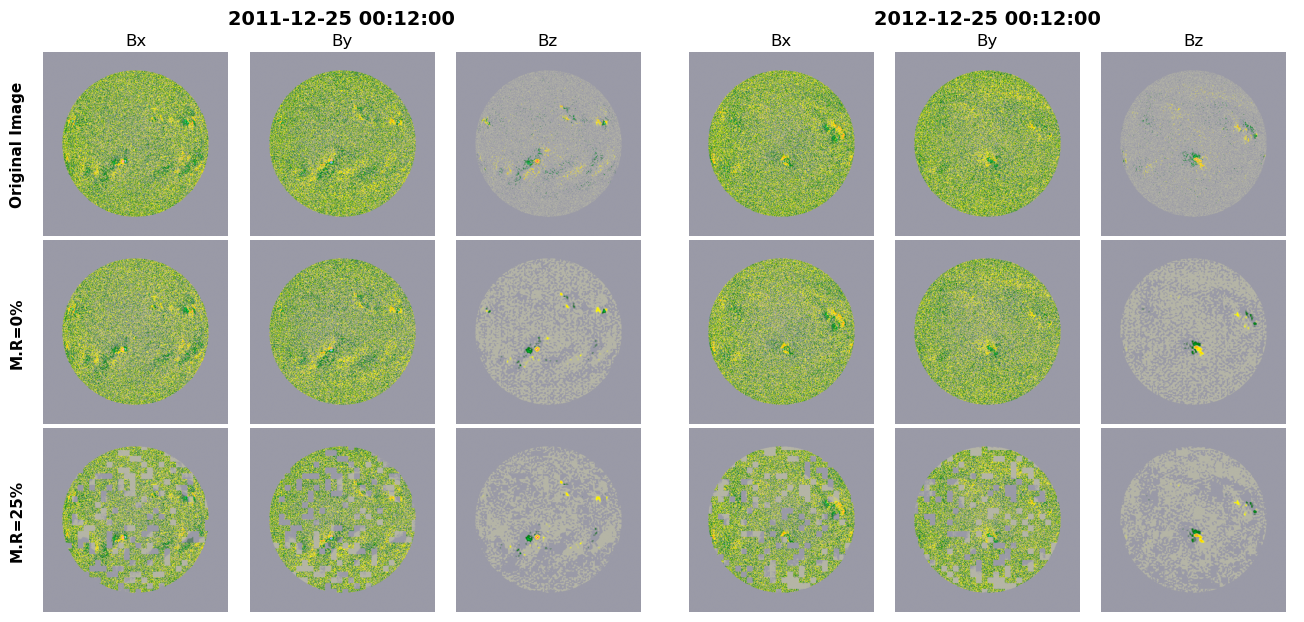

In [9]:
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)
hmi_cmap= color_tables.hmi_mag_color_table()

ch_info = ["Bx", "By", "Bz"]
row_labels = ["Original Image", "M.R=0%", "M.R=25%"]

fig = plt.figure(figsize=(14, 7)) 
outer_gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1], 
                             wspace=0.05, left=0.05, right=0.95, top=0.9, bottom=0.1)


for t_i, timestamp in enumerate(ts):
    
    inner_gs = gridspec.GridSpecFromSubplotSpec(3, 3, 
                                                subplot_spec=outer_gs[t_i], 
                                                wspace=0.02, hspace=0.02)

    ax_block_title = fig.add_subplot(outer_gs[t_i])
    ax_block_title.set_title(f"{timestamp}", fontsize=14, fontweight='bold', pad=20) 
    ax_block_title.axis('off')

    for r_i in range(3): 
        for c_i, ch_name in enumerate(ch_info): 
            
            ax = fig.add_subplot(inner_gs[r_i, c_i])
            
            # --- Data Selection Logic ---
            if r_i == 0:   # Original
                data = x_set[t_i, c_i, 0, :, :]
            elif r_i == 1: # M.R = 0%
                data = output_no_mask[0][t_i, c_i, 0, :, :] * model.limb_mask
            elif r_i == 2: # M.R = 25%
                data = output[0][t_i, c_i, 0, :, :] * model.limb_mask
            
            # Plot
            im = ax.imshow(data.to("cpu").numpy(), cmap=hmi_cmap, norm=norm)
            
            # Styling
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

            # --- Headers & Labels ---
            if r_i == 0:
                ax.set_title(ch_name, fontsize=12, fontweight='medium', pad=5) # Reduced pad

            if t_i == 0 and c_i == 0:
                ax.text(-0.1, 0.5, row_labels[r_i],  # Moved closer (-0.1 instead of -0.2)
                        transform=ax.transAxes, 
                        ha='right', va='center', 
                        fontsize=11, fontweight='bold', rotation=90)

plt.savefig(f"SDOFMv2_HMI_results_mask_ratio.pdf", dpi=300, bbox_inches="tight")
plt.show()